# Setup

In [5]:
# main
import pandas as pd
import numpy as np
from scipy import stats

# models
import statsmodels.api as sm
from statsmodels.regression.quantile_regression import QuantReg
from sklearn.linear_model import QuantileRegressor
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA

# diagnositcs
import shap
from statsmodels.iolib.summary2 import summary_col
from sklearn.metrics import r2_score


# preprocessing
from statsmodels.tsa.tsatools import add_trend
from sklearn.preprocessing import StandardScaler
from feature_engine.timeseries.forecasting import LagFeatures

# feature selection
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import TimeSeriesSplit

# tests
from statsmodels.tsa.stattools import adfuller, coint

# charts
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly

# util
from mat4py import loadmat
from IPython.display import display

In [6]:
class StandardScalerDF:

    def __init__(self, mean=None, std=None):
        self.mean_ = mean
        self.std_ = std

    def fit(self, X):
        self.mean_ = X.mean()
        self.std_ = X.std()
        return self

    def transform(self, X):
        if self.mean_ is None or self.std_ is None:
            raise ValueError("Scaler has not been fit yet.")
        scaled_X = (X - self.mean_) / self.std_
        return scaled_X

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

    def inverse_transform(self, X_scaled):
        if self.mean_ is None or self.std_ is None:
            raise ValueError("Scaler has not been fit yet.")
        X = X_scaled * self.std_ + self.mean_
        return X

In [7]:
# Kalman filter: Kalman_companion method below
def kalman_companion(data, S0, P0, L, R, T, Q):
    # scalar setup
    t, nvars = data.shape
    nstates_all = S0.shape[0]
    nstates = L.shape[0]

    # matrix setup
    S_pred = S0
    P_pred = P0
    S = np.zeros((data.shape[0], nstates_all))
    P = np.zeros((nstates_all**2, t))

    # Kalman filter step, extracting states
    for index, (date, y_i) in enumerate(data.iterrows()):
        nu = np.array(y_i) - L.T @ S_pred[:nstates]  # conditional forecast error
        f = L.T @ P_pred[:nstates, :nstates] @ L + R  # variance of the conditional forecast error
        finv = L @ np.linalg.inv(f)
        Stt = S_pred + (P_pred[:, :nstates] @ finv @ nu)
        Ptt = P_pred - P_pred[:, :nstates] @ finv @ (L.T @ P_pred[:nstates, :])
        if date < data.index[-1]:
            S_pred = T @ Stt
            P_pred = T @ Ptt @ T.T + Q
        S[index, :] = Stt
        P[:, index] = Ptt.reshape(-1)

    # Now we can draw Sdraw(T|T) ~ N(S(T|T), P(T|T))
    S_draw = np.zeros((t, nstates_all))
    S_draw[t-1, :] = S[t-1, :]

    # iterate 'down', drawing at each step, use modification for singular Q
    T_star = T[:nstates, :]
    Q_star = Q[:nstates, :nstates]

    # Kalman Smoothing step
    for i in range(1, t)[::-1]:
        Sf = S_draw[i, :nstates]
        Stt = S[i-1, :]
        Ptt = P[:, i-1].reshape(nstates_all, -1)
        f = T_star @ Ptt @ T_star.T + Q_star
        finv = T_star.T @ np.linalg.inv(f)
        nu = Sf - T_star @ Stt
        Smean = Stt + Ptt @ finv @ nu
        # Svar = Ptt - Ptt @ finv @ (T_star @ Ptt)
        S_draw[i-1, :] = Smean
    S_draw = S_draw[:, :nstates]
    return S_draw

In [87]:
def Minn_prior_KOOP(gamma, nstates, nlags, nvars):
    # This is the version of the Minnesota prior with no dependence on the
    # standard deviations of the univariate regressions. This prior allows
    # online estimation and forecasting of the large TVP-VAR.

    # 1. Minnesota Mean on VAR regression coefficients
    A_prior = np.concatenate((0.9*np.eye(nstates),
                              np.zeros(((nlags-1)*nstates, nstates))), axis=0).T
    a_prior = A_prior.T.reshape(-1)

    # 2. Minnesota Variance on VAR regression coefficients
    # Create an array of dimensions nvars x nstates, which will contain the nvars diagonal
    # elements of the covariance matrix, in each of the nstates equations.
    V_i = np.zeros((int(nvars/nstates), nstates))

    for i in range(nstates):
        for j in range(int(nvars/nstates)):
            V_i[j, i] = gamma / (np.ceil((j+1)/nstates))**2

    # 3. Now V (MINNESOTA VARIANCE) is a diagonal matrix with diagonal elements of V_i
    V_prior = np.diag(V_i.reshape(-1))  # this is the prior variance of the vector alpha
    return a_prior, V_prior

In [220]:
def create_RHS_NI(YY, nstates, nlags, t):
    K = nlags*(nstates**2) # K is the number of elements in the state vector
    
    # Create x_t matrix
    # first find the zeros in matrix x_t
    x_t = np.zeros(((t-nlags)*nstates, K))
    for i in range(t-nlags):
        ztemp = np.array([]).reshape(nstates, -1)
        for j in range(nlags):
            xtemp = YY[i, j*nstates:(j+1)*nstates]
            xtemp = np.kron(np.eye(nstates), xtemp)
            ztemp = np.concatenate((ztemp, xtemp), axis=1)
        x_t[i*nstates:(i+1)*nstates, :] = ztemp
    return x_t, K

# Financial Conditions Index (FCI)

In [608]:
# meta information
data_dates = pd.date_range('1959Q1', '2012Q1', freq='QS')
X_varnames = loadmat("../FCI/DMA_FCI/data/varnames.mat")['varnames']
X_varnames = [v for line in X_varnames for v in line]
Y_varnames = ['Inflation', 'Infl. Exp.', 'GDP', 'Unemployemnt', 'M1', 'FedFunds']

# exog
X = pd.read_csv("../FCI/DMA_FCI/data/xdata.dat", delimiter='\t', header=None)
X = X.set_index(data_dates)
X.columns = X_varnames

# endog
Y = pd.read_csv("../FCI/DMA_FCI/data/ydata.dat", delimiter='\t', header=None)
Y = Y.set_index(data_dates)
Y.columns = Y_varnames
# Using: Inflation, GDP, FedFunds (rate)
Y = Y[['Inflation', 'GDP', 'FedFunds']].copy()

In [9]:
# standardize data
ss = StandardScalerDF()
X_st = ss.fit_transform(X)
Y_st = ss.fit_transform(Y)

# fillna with 0
X_st = X_st.fillna(0)

# standardize again for some reason
X_st = ss.fit_transform(X_st)

FCI using PCA

In [10]:
pca_model = PCA(n_components=1, svd_solver='full', tol=0,
                iterated_power='auto', n_oversamples=10,
                power_iteration_normalizer='auto', 
                random_state=42)
pca_model.fit(X_st)
n = X_st.shape[1]
pca_loadings = - pca_model.components_.T * np.sqrt(n)
fci_pca = (X_st @ (pca_loadings / n)).squeeze().rename('fci_pca')
print('Explained Variance:', pca_model.explained_variance_ratio_[0].round(4))
print('Singular values:', pca_model.singular_values_[0].round(4))

Explained Variance: 0.2542
Singular values: 32.8288


FCI using the method by Doz, Giannone and Reichlin (2011)

In [11]:
t = Y_st.shape[0]
YF = pd.concat([Y_st, fci_pca], axis=1)
YX = pd.concat([Y_st, X_st], axis=1)
t, nvars = YX.shape
nlags = 4
nstates = YF.shape[1]
n_undefined_rows = nstates*(nlags-1)
nstates_doz = nstates*nlags

# measurement model
measurement_model = sm.OLS(YX, YF).fit()
L = np.array(measurement_model.params)
e = measurement_model.resid
measurement_sigma = np.diag(np.diag((e.T @ e) / t))
R = measurement_sigma + 1e-10*np.eye(nvars)
# sigma2 = np.diag((e**2).sum() / t)

# state model
lf = LagFeatures(periods=list(range(1, nlags+1)), drop_original=True)
yf_lags = lf.fit_transform(YF).dropna()
yf_lags_cov_inv = np.linalg.inv(yf_lags.T @ yf_lags)
yf = YF.loc[yf_lags.index].copy()
t = yf.shape[0]
state_model = sm.OLS(yf, yf_lags).fit()
T = np.array(state_model.params)
e = state_model.resid
sigmaf = (e.T @ e) / (t-1)
state_beta_var = np.kron(sigmaf, yf_lags_cov_inv)
bb = T.reshape(nstates, nlags, nstates).transpose(0, 2, 1).reshape(-1)

# state model as VAR
ar_identity = np.concatenate((np.eye(n_undefined_rows), np.zeros((n_undefined_rows, nstates))), axis=1)
T_doz = np.concatenate((T.T, ar_identity), axis=0)
Q_doz = np.concatenate((sigmaf, np.zeros((nstates, n_undefined_rows))), axis=1)
Q_doz = np.concatenate((Q_doz, np.zeros((n_undefined_rows, nstates_doz))), axis=0)

# drawing states from Kalman filter (smoothing)
S0 = np.zeros(nstates_doz)
P0 = 10*np.eye(nstates_doz)
S_draws = kalman_companion(YX, S0, P0, L, R, T_doz, Q_doz)
S_draws = pd.DataFrame(S_draws, index=YF.index, columns=YF.columns).rename(columns={'fci_pca': 'fci_doz'})
fci_doz = S_draws['fci_doz']

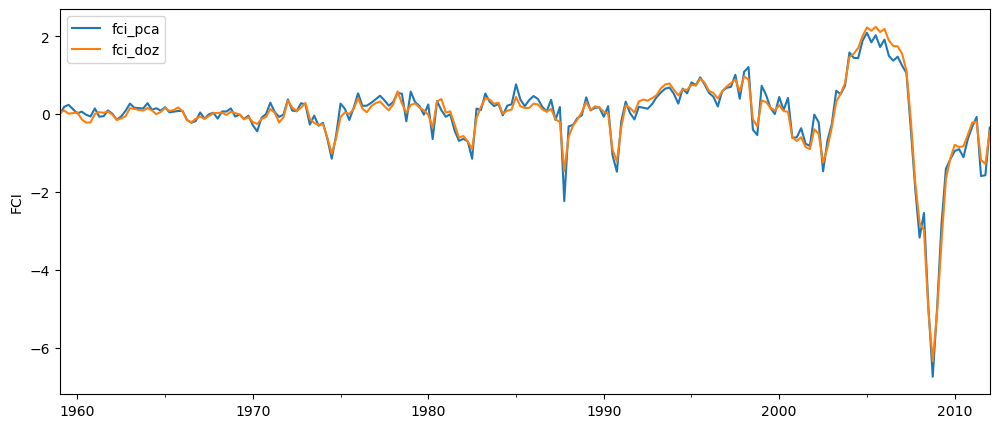

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))
ss.fit_transform(fci_pca).plot(ax=ax)
ss.fit_transform(fci_doz).plot(ax=ax)
plt.ylabel("FCI")
plt.legend()
# plt.savefig('../results/fci_pca.png', bbox_inches='tight', dpi=300)
plt.show()

FCI using the method by Koop and Korobilis (2013)

In [695]:
# step 1: Update Parameters Conditional on PC
# the  decays include:
# 1) decay factor for measurement error variance
# 2) decay factor for factor error variance
# 3) decay factor for loadings error variance
# 4) decay factor for VAR coefficients error variance
decays = np.array([0.96, 0.96, 0.99, 0.99])
nfactors = 1
nlags = 4
nstates = YF.shape[1]
nmacro = nstates - nfactors
t, nvars = YX.shape
nstates_all = nstates*nlags
nVAR = nlags*(nstates**2)  # number of VAR parameters

# Priors
priors = {}

# initial condition on the factors
priors['factor_0_mean'] = np.zeros(nstates_all)
priors['factor_0_var'] = 10*np.eye(nstates_all)

# initial condition on lambda_t
priors['lambda_0_mean'] = np.zeros((nvars, nstates))
priors['lambda_0_var'] = 1*np.eye(nstates)

# initial condition on beta_t
gamma = 0.1
b_prior, Vb_prior = Minn_prior_KOOP(gamma, nstates, nlags, nVAR)  # Obtain a Minnesota-type prior
priors['beta_0_mean'] = b_prior
priors['beta_0_var'] = Vb_prior

# initial condition on the covariance matrices
priors['V_0'] = 0.1*np.eye(nvars)
priors['V_0'][:nmacro, :nmacro] = 0
priors['Q_0'] = 0.1*np.eye(nstates)

# KFS_parameters
beta_t, beta_new, lambda_t, V_t, Q_t = KFS_parameters(YX, YF, decays, nfactors, nlags, priors)

# step 2: Update Factors Conditional on TV-Parameters

In [990]:
class TVP_FAVAR():
    # Function to estimate time-varying loadings, coefficients, and covariances
    # from a TVP-FAVAR, conditional on feeding in an estimate of the factors
    # (Principal Components). This function runs the Kalman filter and smoother
    # for all time-varying parameters using an adaptive algorithm (EWMA filter
    # for the covariances).
    # Written by Dimitris Korobilis, 2012
    def __init__(self, endog, exog, nlags):
        nstates = exog.shape[1]
        t, nvars = endog.shape
        self.nlags = nlags
        self.nmacro = nstates - nfactors
        nstates_all = nstates*self.nlags
        nVAR = self.nlags*(nstates**2)

        # setup: lambda
        self.lambda_pred = np.zeros((nvars, nstates, t))
        self.lambda_update = np.zeros((nvars, nstates, t))

        for i in range(t):
            self.lambda_pred[:nstates, :nstates, i] = np.eye(nstates)
            self.lambda_update[:nstates, :nstates, i] = np.eye(nstates)

        # setup: beta
        self.beta_pred = np.zeros((nVAR, t))
        self.beta_update = np.zeros((nVAR, t))

        # setup: states
        self.Rl_t = np.zeros((nstates, nstates, nvars, t))
        self.Sl_t = np.zeros((nstates, nstates, nvars, t))
        self.Rb_t = np.zeros((nVAR, nVAR, t))
        self.Sb_t = np.zeros((nVAR, nVAR, t))

        # setup: expectations
        self.x_t_pred = np.zeros((t, nvars))
        self.e_t = np.zeros((nvars, t))
        self.lambda_t = np.zeros((nvars, nstates, t))
        self.beta_t = np.zeros((nstates_all, nstates_all, t))

        # setup: covariance
        self.Q_t = np.zeros((nstates, nstates, t))
        self.V_t = np.zeros((nvars, nvars, t))

        # define lags of the factors to be used in the state (VAR) equation
        lf = LagFeatures(periods=list(range(1, self.nlags+1)), drop_original=True)
        xx = lf.fit_transform(exog).dropna()
        yy = exog.loc[xx.index].copy()
        self.xx = np.array(xx)
        self.yy = np.array(yy)
        self.exog = np.array(exog)
        self.endog = np.array(endog)
        Flagtemp, m = create_RHS_NI(self.xx.copy(), nstates, self.nlags, t)
        self.Flag = np.concatenate((np.zeros((nstates_all, nVAR)), Flagtemp), axis=0)

    def kalman_setup(self, priors):
        # init
        t, nvars = self.endog.shape
        self.Q_t[:, :, 0] = priors['Q_0']
        self.V_t[:, :, 0] = np.diag(np.diag(priors['V_0']))
        self.lambda_pred[:, :, 0] = priors['lambda_0_mean']
        self.beta_pred[:, 0] = priors['beta_0_mean']
        self.beta_update[:, 0] = self.beta_pred[:, 0]
        self.Rb_t[:, :, 0] = priors['beta_0_var']
        for i in range(self.nmacro, nvars):
            self.Rl_t[:, :, i, 0] = priors['lambda_0_var']

    def kalman_update_coeffs(self, t):
        nstates = self.exog.shape[1]
        # Update VAR coefficients conditional on Principal Componets estimates
        Rx = self.Rb_t[:, :, t] @ self.Flag[t*nstates:(t+1)*nstates, :].T
        KV_b = self.Q_t[:, :, t] + self.Flag[t*nstates:(t+1)*nstates, :]  @ Rx
        KG = Rx @ np.linalg.inv(KV_b)
        beta_adj = KG @ (self.exog[t, :].T - self.Flag[t*nstates:(t+1)*nstates, :] @ self.beta_pred[:, t])
        self.beta_update[:, t] = self.beta_pred[:, t] + beta_adj
        Sb_adj = KG @ (self.Flag[t*nstates:(t+1)*nstates, :] @ self.Rb_t[:, :, t])
        self.Sb_t[:, :, t] = self.Rb_t[:, :, t] - Sb_adj

    def kalman_filter_early(self, t, decays, priors):
        nstates = self.exog.shape[1]
        exog_i = self.exog[t, :]

        # priors
        self.beta_pred[:, t] = priors['beta_0_mean']
        self.beta_update[:, t] = self.beta_pred[:, t]
        self.Rb_t[:, :, t] = priors['beta_0_var']

        # expectations
        Gf_t = 0.1*(exog_i.reshape(-1, 1) @ exog_i.reshape(1, -1))
        if t > 0:
            self.Q_t[:, :, t] = decays[1]*self.Q_t[:, :, t-1] + (1-decays[1])*Gf_t[:nstates, :nstates]

    def kalman_filter(self, t, decays):
        nstates = self.exog.shape[1]
        nstates_all = nstates*self.nlags
        yy_i = self.yy[t-self.nlags]
        xx_i = self.xx[t-self.nlags]

        # expectations
        ee_i = (yy_i - xx_i @ self.B[:nstates, :nstates_all].T)
        Gf_t = ee_i.reshape(-1, 1) @ ee_i.reshape(1, -1)
        self.Q_t[:, :, t] = decays[1]*self.Q_t[:, :, t-1] + (1-decays[1])*Gf_t[:nstates, :nstates]

        # update beta
        self.beta_pred[:, t] = self.beta_update[:, t-1]
        self.Rb_t[:, :, t] = (1 / decays[3]) * self.Sb_t[:, :, t-1]

    def kalman_predict(self, t, decays):
        nstates = self.exog.shape[1]
        nvars = self.endog.shape[1]
        n_undefined_rows = nstates*(self.nlags-1)
        p = self.nmacro

        # Kalman predict steps
        if t > 0:
            self.lambda_pred[:, :, t] = self.lambda_update[:, :, t-1]
            self.Rl_t[:, :, :, t] = (1/decays[2])*self.Sl_t[:, :, :, t-1]

        # One step ahead prediction based on PC factor
        self.x_t_pred[t, :] = self.lambda_pred[:, :, t] @ self.exog[t, :].T

        # Prediction error
        self.e_t[:, t] = self.endog[t, :] - self.x_t_pred[t, :]

        # Get the measurement error variance
        self.A_t = self.e_t[self.nmacro:, t].reshape(-1, 1) @ self.e_t[self.nmacro:, t].reshape(1, -1)
        if t > 0:
            self.V_t[p:, p:, t] = decays[0]*self.V_t[p:, p:, t-1] + (1-decays[0])*np.diag(np.diag(self.A_t))

        # Update loadings conditional on Principal Components estimates
        for i in range(self.nmacro, nvars):
            Rx = self.Rl_t[:nstates, :nstates, i, t] @ self.exog[t, :nstates].T
            KV_l = self.V_t[i, i, t] + self.exog[t, :nstates] @ Rx
            KG = Rx / KV_l
            lambda_adj = KG * (self.endog[t, i].T - self.lambda_pred[i, :nstates, t] @ self.exog[t, :nstates].T)
            self.lambda_update[i, :nstates, t] = self.lambda_pred[i, :nstates, t] + lambda_adj
            Sl_adj = KG.reshape(-1, 1) @ (self.exog[t, :nstates] @ self.Rl_t[:nstates, :nstates, i, t]).reshape(1, -1)
            self.Sl_t[:nstates, :nstates, i, t] = self.Rl_t[:nstates, :nstates, i, t] - Sl_adj

        # update coeffs
        if t >= self.nlags:
            self.kalman_update_coeffs(t)

        # Assign coefficients
        biga = self.beta_update[:, t].reshape(nstates, self.nlags, nstates).transpose(1, 0, 2).reshape(nstates, -1)
        b_other = np.concatenate((np.eye(n_undefined_rows), np.zeros((n_undefined_rows, nstates))), axis=1)
        self.B = np.concatenate((biga, b_other), axis=0)
        self.lambda_t[:, :, t] = self.lambda_update[:, :, t]
        if np.max(np.abs(np.linalg.eig(self.B)[0])) < 0.9999:
            self.beta_t[:, :, t] = self.B
        else:
            self.beta_t[:, :, t] = self.beta_t[:, :, t-1]
            self.beta_update[:, t] = 0.95*self.beta_update[:, t-1]

    def smoother_setup(self, t):
        self.lambda_new = 0*self.lambda_update
        self.lambda_new[:, :, t] = self.lambda_update[:, :, t]
        self.beta_new = 0*self.beta_update
        self.beta_new[:, t] = self.beta_update[:, t]
        self.Q_t_new = 0*self.Q_t
        self.Q_t_new[:, :, t] = self.Q_t[:, :, t]
        self.V_t_new = 0*self.V_t
        self.V_t_new[:, :, t] = self.V_t[:, :, t]

    def kalman_smoother(self, t):
        # init
        nstates = self.exog.shape[1]
        nvars = self.endog.shape[1]
        p = self.nmacro

        # smooth lambda
        self.lambda_new[:nstates, :, t] = self.lambda_update[:nstates, :, t]
        for i in range(nstates, nvars):
            self.Ul_t = self.Sl_t[:nstates, :nstates, i, t] / np.linalg.inv(self.Rl_t[:nstates, :nstates, i, t+1])
            lambda_adj = self.lambda_new[i, :nstates, t+1] - self.lambda_pred[i, :nstates, t+1] @ self.Ul_t.T
            self.lambda_new[i, :nstates, t] = self.lambda_update[i, :nstates, t] + lambda_adj

        # smooth beta
        if np.sum(self.Rb_t[:, :, t+1]) == 0:
            self.beta_new[:, t] = self.beta_update[:, t]
        else:
            Ub_t = self.Sb_t[:, :, t] @ np.linalg.inv(self.Rb_t[:, :, t+1])
            self.beta_new[:, t] = self.beta_update[:, t] + Ub_t @ (self.beta_new[:, t+1] - self.beta_pred[:, t+1])

        # smooth Q_t
        self.Q_t_new[:, :, t] = 0.9*self.Q_t[:, :, t] + 0.1*self.Q_t_new[:, :, t+1]

        # smooth V_t
        self.V_t_new[p:, p:, t] = 0.9*self.V_t[p:, p:, t] + 0.1*self.V_t_new[p:, p:, t+1]

    def kalman_reassign_coefficients(self, t):
        nstates = self.exog.shape[1]
        n_undefined_rows = nstates*(self.nlags-1)
        biga = self.beta_new[:, t].reshape(nstates, self.nlags, nstates).transpose(1, 0, 2).reshape(nstates, -1)
        b_other = np.concatenate((np.eye(n_undefined_rows), np.zeros((n_undefined_rows, nstates))), axis=1)
        B = np.concatenate((biga, b_other), axis=0)
        self.lambda_t[:, :, t] = self.lambda_new[:, :, t]
        self.beta_t[:, :, t] = B

    def fit(self, nfactors, decays, priors):
        # initialize matrices for filtering
        t = self.endog.shape[0]
        self.kalman_setup(priors)

        # perform predictions at time t=0
        self.kalman_predict(0, decays)

        # 1. Kalman filter
        for irep in range(1, t):
            # Update the state covariances,
            # get the variance of the factor and update Q[t]
            if irep <= self.nlags:
                self.kalman_filter_early(irep, decays, priors)
            else:
                self.kalman_filter(irep, decays)
            self.kalman_predict(irep, decays)

        # 2. Kalman smoother
        self.smoother_setup(t-1)
        for irep in range(t-2, -1, -1):
            self.kalman_smoother(irep)

        # using smoothed values for beta and lambda
        for irep in range(t):
            self.kalman_reassign_coefficients(irep)
        return self.beta_t, self.beta_new, self.lambda_t, self.V_t, self.Q_t

In [991]:
tvp_favar_korobilis = TVP_FAVAR(YX, YF, nlags)
beta_t, beta_new, lambda_t, V_t, Q_t = tvp_favar_korobilis.fit(nfactors, decays, priors)